In [3]:
import torch

In [15]:
x = torch.arange(48)
x=x.reshape(6,8)
print(x)
x=x.reshape(2,-1,8)
print(x)
x=x.reshape(4,3,-1,2)
print(x)
x=x.reshape(-1,12)
print(x)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20, 21, 22, 23],
        [24, 25, 26, 27, 28, 29, 30, 31],
        [32, 33, 34, 35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44, 45, 46, 47]])
tensor([[[ 0,  1,  2,  3,  4,  5,  6,  7],
         [ 8,  9, 10, 11, 12, 13, 14, 15],
         [16, 17, 18, 19, 20, 21, 22, 23]],

        [[24, 25, 26, 27, 28, 29, 30, 31],
         [32, 33, 34, 35, 36, 37, 38, 39],
         [40, 41, 42, 43, 44, 45, 46, 47]]])
tensor([[[[ 0,  1],
          [ 2,  3]],

         [[ 4,  5],
          [ 6,  7]],

         [[ 8,  9],
          [10, 11]]],


        [[[12, 13],
          [14, 15]],

         [[16, 17],
          [18, 19]],

         [[20, 21],
          [22, 23]]],


        [[[24, 25],
          [26, 27]],

         [[28, 29],
          [30, 31]],

         [[32, 33],
          [34, 35]]],


        [[[36, 37],
          [38, 39]],

         [[40, 41],
          [42, 43]],

         [[44, 45

In [19]:
X = torch.arange(12).reshape(3, 4)
Y = torch.tensor([
    [0, 2, 1, 5],
    [4, 3, 7, 6],
    [9, 8, 10, 12]
])
(X<Y).shape

torch.Size([3, 4])

In [28]:
X = torch.arange(48).reshape(2, 3, 8)
X[0]
X[:,1,:]
X[:,:,6:8]
X.reshape(6,8)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20, 21, 22, 23],
        [24, 25, 26, 27, 28, 29, 30, 31],
        [32, 33, 34, 35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44, 45, 46, 47]])

In [29]:
import pandas as pd

data = pd.DataFrame({
    "age": [18, 20, None, 21],
    "score": [88, None, 92, 79],
    "city": ["Guangzhou", "Beijing", "Guangzhou", None],
    "label": [1, 0, 1, 0]
})

print(data)

    age  score       city  label
0  18.0   88.0  Guangzhou      1
1  20.0    NaN    Beijing      0
2   NaN   92.0  Guangzhou      1
3  21.0   79.0       None      0


In [31]:
print(data.columns)
print(data.head())

Index(['age', 'score', 'city', 'label'], dtype='object')
    age  score       city  label
0  18.0   88.0  Guangzhou      1
1  20.0    NaN    Beijing      0
2   NaN   92.0  Guangzhou      1
3  21.0   79.0       None      0


In [32]:
data.isna().sum()

age      1
score    1
city     1
label    0
dtype: int64

In [33]:
encoded = pd.get_dummies(data, columns=["city"], dummy_na=True, dtype=float)

print(encoded)

    age  score  label  city_Beijing  city_Guangzhou  city_nan
0  18.0   88.0      1           0.0             1.0       0.0
1  20.0    NaN      0           1.0             0.0       0.0
2   NaN   92.0      1           0.0             1.0       0.0
3  21.0   79.0      0           0.0             0.0       1.0


In [36]:
data = pd.DataFrame({
    "age": [18, 20, None, 21, 19, 22],
    "score": [88, None, 92, 79, 95, 85],
    "city": ["Guangzhou", "Beijing", "Guangzhou", None, "Shanghai", "Beijing"],
    "unused": [None, None, 1, None, None, None],
    "label": [1, 0, 1, 0, 1, 0]
})
print(data)

    age  score       city  unused  label
0  18.0   88.0  Guangzhou     NaN      1
1  20.0    NaN    Beijing     NaN      0
2   NaN   92.0  Guangzhou     1.0      1
3  21.0   79.0       None     NaN      0
4  19.0   95.0   Shanghai     NaN      1
5  22.0   85.0    Beijing     NaN      0


In [35]:
data.isna().sum()

age       1
score     1
city      1
unused    5
label     0
dtype: int64

In [38]:
import pandas as pd
import torch

# 原始数据
data = pd.DataFrame({
    "age": [18, 20, None, 21, 19, 22],
    "score": [88, None, 92, 79, 95, 85],
    "city": [
        "Guangzhou",
        "Beijing",
        "Guangzhou",
        None,
        "Shanghai",
        "Beijing"
    ],
    "unused": [None, None, 1, None, None, None],
    "label": [1, 0, 1, 0, 1, 0]
})

# 1. 统计每列缺失值
missing_counts = data.isna().sum()
print("各列缺失值数量：")
print(missing_counts)

# 2. 删除缺失值最多的列
most_missing_column = missing_counts.idxmax()
data = data.drop(columns=[most_missing_column])

print("\n删除的列：", most_missing_column)

# 3. 数值特征列使用均值填补
# label 是答案，不参与缺失值填补
numeric_columns = ["age", "score"]

for column in numeric_columns:
    mean_value = data[column].mean()
    data[column] = data[column].fillna(mean_value)

# 4. 类别列使用一个专门的缺失类别填补
data["city"] = data["city"].fillna("Unknown")

print("\n填补缺失值后的数据：")
print(data)

# 5. 对无序类别 city 进行独热编码
encoded = pd.get_dummies(
    data,
    columns=["city"],
    dtype=float
)

print("\n独热编码后的数据：")
print(encoded)

# 6. 分离特征 X 和标签 y
features = encoded.drop(columns=["label"])
labels = encoded["label"]

# 7. 转换成 PyTorch Tensor
X = torch.tensor(
    features.to_numpy(dtype="float32"),
    dtype=torch.float32
)

y = torch.tensor(
    labels.to_numpy(),
    dtype=torch.long
)

# 8. 打印 shape、dtype 和最终数据
print("\nX 的 shape：", X.shape)
print("X 的 dtype：", X.dtype)
print("X 的数据：")
print(X)

print("\ny 的 shape：", y.shape)
print("y 的 dtype：", y.dtype)
print("y 的数据：")
print(y)

各列缺失值数量：
age       1
score     1
city      1
unused    5
label     0
dtype: int64

删除的列： unused

填补缺失值后的数据：
    age  score       city  label
0  18.0   88.0  Guangzhou      1
1  20.0   87.8    Beijing      0
2  20.0   92.0  Guangzhou      1
3  21.0   79.0    Unknown      0
4  19.0   95.0   Shanghai      1
5  22.0   85.0    Beijing      0

独热编码后的数据：
    age  score  label  city_Beijing  city_Guangzhou  city_Shanghai  \
0  18.0   88.0      1           0.0             1.0            0.0   
1  20.0   87.8      0           1.0             0.0            0.0   
2  20.0   92.0      1           0.0             1.0            0.0   
3  21.0   79.0      0           0.0             0.0            0.0   
4  19.0   95.0      1           0.0             0.0            1.0   
5  22.0   85.0      0           1.0             0.0            0.0   

   city_Unknown  
0           0.0  
1           0.0  
2           0.0  
3           1.0  
4           0.0  
5           0.0  

X 的 shape： torch.Size([6, 6])
X 

In [40]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 3

y.backward()
y = x**3
y.backward()

In [41]:
import torch

x = torch.tensor(2.0, requires_grad=True)

# 第一次前向与反向
y = x ** 2
y.backward()

print(x.grad)  # tensor(4.)

tensor(4.)


In [42]:
y = x ** 2
y.backward()

print(x.grad)  # tensor(4.)

tensor(8.)


In [43]:
x.grad.zero_()
print(x.grad)

tensor(0.)


In [44]:
y = x ** 2
y.backward()

print(x.grad)  # tensor(4.)

tensor(4.)


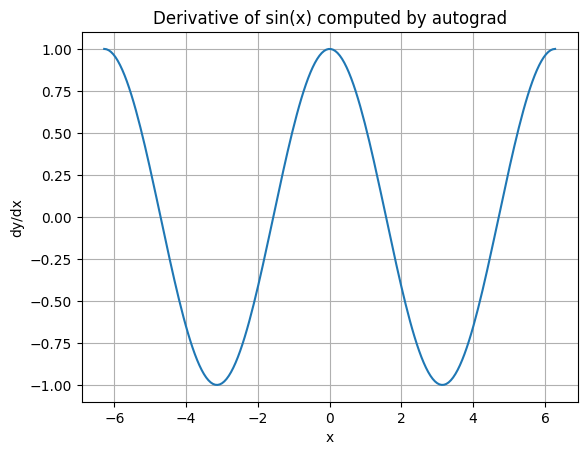

In [45]:
import torch
import matplotlib.pyplot as plt

# 生成 -2π 到 2π 的 200 个点
xs = torch.linspace(
    -2 * torch.pi,
    2 * torch.pi,
    200
)

grad_values = []

for value in xs:
    # 创建一个独立、可追踪梯度的标量
    x = value.clone().detach().requires_grad_(True)

    # 前向计算
    y = torch.sin(x)

    # 反向传播
    y.backward()

    # 保存 dy/dx
    grad_values.append(x.grad.item())

# 绘制自动微分得到的导数
plt.plot(xs.numpy(), grad_values)
plt.xlabel("x")
plt.ylabel("dy/dx")
plt.title("Derivative of sin(x) computed by autograd")
plt.grid()
plt.show()

In [46]:
import os
print(os.getcwd())

C:\Users\12793\deep-learning-onboarding
